# Classifier choice stability

Cluster LOCO-Split requires choosing a classifier. Investigate the choice of classifier on 4 canonical simulations with different difficulties. 
1) 3-GMM canonical example (2 signal features, 3 noise features)
2) Non linearly separable toy example (3 signal features, 2 noise feature)
3) 5-GMM with correlated features (Toeplitz correlation with $\rho = 0.2$, 5 signal features, 5 noise features)
4) 5-GMM with correlated features (Toeplitz correlation with $\rho = 0.8$, 5 signal features, 5 noise features)


In [30]:
import sys
sys.path.append('../../')
from simulations.toy_datasets import *
from simulations.mixture_models import *
from clim.data_splitting import Cluster_LOCO_Split
from clim.utils.utils import *
from clim.utils.non_conformity_scores import *
import numpy as np
import matplotlib.pyplot as plt

## Linearly separable example

In [59]:
K, N, P = 3, 100, 2
seed = 42
rng = np.random.default_rng(seed)
X, labels = gaussian_mixture(K, N, P, alpha=2, method='simplex', random_state=seed)
X = np.concatenate([X, rng.normal(size=(K*N, 3))], axis=1)

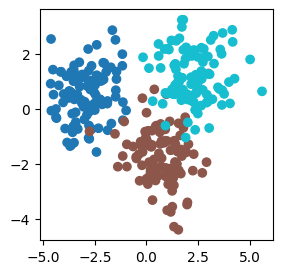

In [60]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(3,3))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10')

In [61]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tqdm
K = 3
model = KMeans(n_clusters=K)
X_tr, X_ca, y_tr, y_ca = train_test_split(X, labels, test_size=0.5, shuffle=True)

In [62]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb 

knn = KNeighborsClassifier(3)
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
svc = SVC(gamma=2, C=1, random_state=42, probability=True)
rfc = RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1, random_state=42)
nb = GaussianNB()
xg = xgb.XGBClassifier(tree_method='hist')

In [63]:
from sklearn.base import clone
T = 100
g_DT, g_xg, g_SVC, g_RF, g_KN, g_NB = np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1])),  np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1]))
for t in tqdm.tqdm(range(T)):
    new = np.random.randint(0, 1000000*T)
    g_DT[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf=dtc, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]
    g_SVC[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =svc, K=3, seed=new, error_metric=hinge_error, use_proba=True, n_jobs=-1)[0]
    g_RF[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =rfc, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]
    g_KN[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =knn, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]
    g_NB[t,:] =  Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =nb, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]
    g_xg[t, :] =  Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =xg, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]


  0%|          | 0/100 [00:00<?, ?it/s]

n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset


  1%|          | 1/100 [00:07<12:25,  7.53s/it]

n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset


  2%|▏         | 2/100 [00:07<05:30,  3.37s/it]

...

 98%|█████████▊| 98/100 [00:43<00:00,  2.69it/s]

n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset


 99%|█████████▉| 99/100 [00:43<00:00,  2.63it/s]

n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset


100%|██████████| 100/100 [00:44<00:00,  2.25it/s]


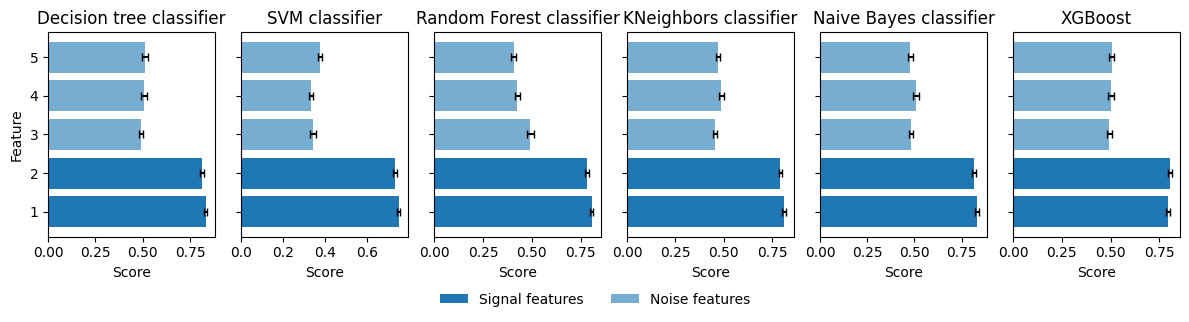

In [64]:
from matplotlib.patches import Patch
fig, ax = plt.subplots(1, 6, figsize=(12, 3), sharey=True)

metrics = [
    (g_DT, "Decision tree classifier"),
    (g_SVC, "SVM classifier"),
    (g_RF, "Random Forest classifier"),
    (g_KN, "KNeighbors classifier"),
    (g_NB, "Naive Bayes classifier"),
    (g_xg, "XGBoost"),
]

y = np.arange(X.shape[1])

colors = ["tab:blue"] * X.shape[1]
alphas = np.array([1.0, 1.0, 0.6, 0.6, 0.6])

def normalize(x):
    return (x - np.min(x))/(np.max(x)-np.min(x))
for a, (g, title) in zip(ax, metrics):
    g = normalize(g)
    mean = np.nanmean(g, axis=0)
    se = np.nanstd(g, axis=0, ddof=1)  / np.sqrt(np.sum(~np.isnan(g), axis=0))

    bars = a.barh(y, mean, xerr=se, capsize=3, color=colors)

    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)

    a.set_title(title)
    a.set_xlabel("Score")
    a.set_yticks(y)
    a.set_yticklabels(np.arange(1, X.shape[1] + 1))
    a.invert_yaxis()

ax[0].set_ylabel("Feature")

legend_handles = [
    Patch(facecolor="tab:blue", alpha=1.0, label="Signal features"),
    Patch(facecolor="tab:blue", alpha=0.6, label="Noise features"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.08),
    frameon=False,
)

plt.tight_layout()
# fig.savefig("../figures/comparison_20runs_toyexample.png", bbox_inches="tight")
plt.show()

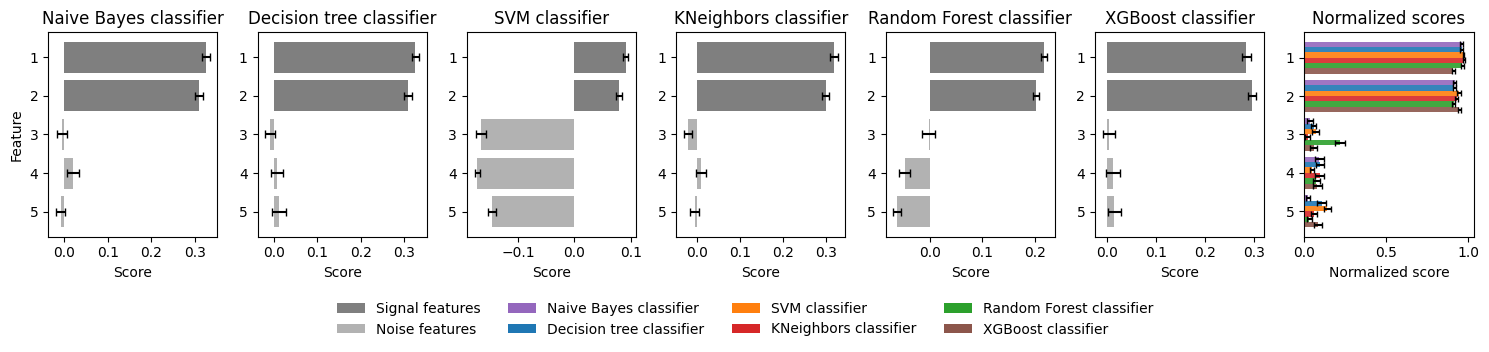

In [66]:
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 7, figsize=(15, 3), sharey=False)
metrics = [
    (g_NB, "Naive Bayes classifier"),
    (g_DT, "Decision tree classifier"),
    (g_SVC, "SVM classifier"),
    (g_KN, "KNeighbors classifier"),
    (g_RF, "Random Forest classifier"),
    (g_xg, "XGBoost classifier"),
]

method_colors = {
    "Decision tree classifier": "tab:blue",
    "SVM classifier": "tab:orange",
    "Random Forest classifier": "tab:green",
    "KNeighbors classifier": "tab:red",
    "Naive Bayes classifier": "tab:purple",
    "XGBoost classifier": "tab:brown",
}

y = np.arange(X.shape[1])

feature_colors = ["tab:gray"] *X.shape[1]
feature_alphas = np.array([1.0, 1.0, 0.6, 0.6, 0.6])

# ---- first five panels: raw scores ----
for a, (g, title) in zip(ax[:-1], metrics):
    mean = np.nanmean(g, axis=0)
    se = np.nanstd(g, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(g), axis=0))

    bars = a.barh(
        y,
        mean,
        xerr=se,
        capsize=3,
        color=feature_colors,
    )

    for bar, alpha in zip(bars, feature_alphas):
        bar.set_alpha(alpha)

    a.set_title(title)
    a.set_xlabel("Score")
    a.set_yticks(y)
    a.set_yticklabels(np.arange(1, X.shape[1] + 1))
    a.invert_yaxis()

ax[0].set_ylabel("Feature")

# ---- sixth panel: normalized scores by method ----
norm_means = []
norm_ses = []
method_names = []

for g, title in metrics:
    # normalize each run across features, then average across runs
    g_norm = np.apply_along_axis(normalize, 1, g)

    norm_means.append(np.nanmean(g_norm, axis=0))
    norm_ses.append(np.nanstd(g_norm, axis=0, ddof=1) /  
                    np.sqrt(np.sum(~np.isnan(g), axis=0)))
    method_names.append(title)

norm_means = np.asarray(norm_means)  # shape: (n_methods, n_features)
norm_ses = np.asarray(norm_ses)

# Put all methods side-by-side for each feature
width = 0.14
offsets = (np.arange(len(metrics)) - (len(metrics) - 1) / 2) * width

for method_idx, title in enumerate(method_names):
    ax[-1].barh(
        y + offsets[method_idx],
        norm_means[method_idx],
        xerr=norm_ses[method_idx],
        height=width,
        capsize=2,
        color=method_colors[title],
        alpha=0.9,
        label=title,
    )

ax[-1].set_title("Normalized scores")
ax[-1].set_xlabel("Normalized score")
ax[-1].set_yticks(y)
ax[-1].set_yticklabels(np.arange(1, X.shape[1] + 1))
ax[-1].invert_yaxis()

# ---- legends ----
feature_legend_handles = [
    Patch(facecolor="tab:gray", alpha=1.0, label="Signal features"),
    Patch(facecolor="tab:gray", alpha=0.6, label="Noise features"),
]

method_legend_handles = [
    Patch(facecolor=method_colors[name], label=name)
    for name in method_names
]

fig.legend(
    handles=feature_legend_handles + method_legend_handles,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.18),
    frameon=False,
)

plt.tight_layout()
# fig.savefig("../figures/comparison_20runs_toyexample.png", bbox_inches="tight")
plt.show()

## Non linearly separable example

In [57]:
from sklearn.preprocessing import StandardScaler

def generate_non_gaussian(n_samples, seed=0):
    # scales = np.array([0.2615908, 0.4728564, 1.0])
    X, y = make_interlaced_halfmoons_3feat(
        n_per_class=n_samples//3,
        noise_xy=0.07,
        noise_f3=0.1,
        seed=seed,
        f3_mode="nonlinear", # "class_offset", 
        f3_offsets=(0.8, -0.1, 0.35)
    )
    X = StandardScaler().fit_transform(X)
    X_perm = np.random.uniform(low=np.min(X), high=np.max(X), size=(X.shape[0], 2))
    
    X = np.concatenate([X, X_perm], axis=1)
    return X, y

n, seed = 1200, 24
X, y = generate_non_gaussian(n_samples=n, seed=seed)
X = X[:, [1, 0, 2, 3, 4]]

In [39]:
from clim.models.sklearn_wrappers import *
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tqdm
K = 3
model = BaseSpectralClustering(n_clusters=K)
X_tr, X_ca, y_tr, y_ca = train_test_split(X, y, test_size=0.5, shuffle=True)

In [40]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

knn = KNeighborsClassifier(3)
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
svc = SVC(gamma=2, C=1, random_state=42, probability=True)
rfc = RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1, random_state=42)
nb = GaussianNB()
xgb = GradientBoostingClassifier(random_state=42)

In [41]:
T = 100
g_DT, g_SVC, g_RF, g_KN, g_NB, g_xg = np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1])),  np.zeros((T, X.shape[1])), np.zeros((T, X.shape[1]))
for t in tqdm.tqdm(range(T)):
    new = np.random.randint(0, 1000000*T)
    g_DT[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf=dtc, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]
    g_SVC[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =svc, K=3, seed=new, error_metric=hinge_error, use_proba=True, n_jobs=-1)[0]
    g_RF[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =rfc, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]
    g_KN[t,:] = Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =knn, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]
    g_NB[t,:] =  Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =nb, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]
    g_xg[t,:] =  Cluster_LOCO_Split(X_tr, X_ca, model=clone(model), clf =xgb, K=3, seed=new, error_metric=hinge_error, n_jobs=-1)[0]

  0%|          | 0/100 [00:00<?, ?it/s]

n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset


  1%|          | 1/100 [00:01<02:14,  1.36s/it]

n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset


  2%|▏         | 2/100 [00:02<02:11,  1.34s/it]

...

 98%|█████████▊| 98/100 [01:58<00:02,  1.21s/it]

n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset


 99%|█████████▉| 99/100 [01:59<00:01,  1.26s/it]

n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset
n_clusters already set to 3; skipping reset


100%|██████████| 100/100 [02:00<00:00,  1.21s/it]


In [42]:
reorder = [0, 2, 1, 3, 4]

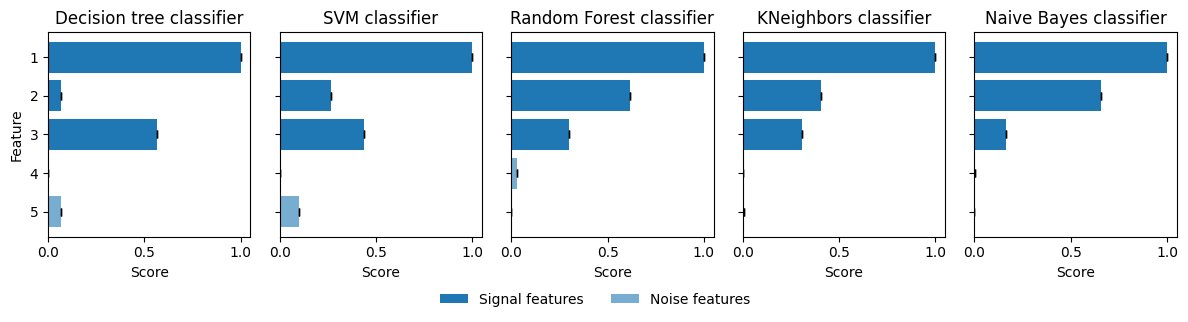

In [43]:
from matplotlib.patches import Patch
fig, ax = plt.subplots(1, 5, figsize=(12, 3), sharey=True)

metrics = [
    (g_DT[:, reorder], "Decision tree classifier"),
    (g_SVC[:, reorder], "SVM classifier"),
    (g_RF[:, reorder], "Random Forest classifier"),
    (g_KN[:, reorder], "KNeighbors classifier"),
    (g_NB[:, reorder], "Naive Bayes classifier"),
]

y = np.arange(X.shape[1])

colors = ["tab:blue"] * X.shape[1]
alphas = np.array([1.0, 1.0, 1.0, 0.6, 0.6])

def normalize(x):
    return (x - np.min(x))/(np.max(x)-np.min(x))
for a, (g, title) in zip(ax, metrics):
    g = normalize(g)
    mean = np.nanmean(g, axis=0)
    se = np.nanstd(g, axis=0, ddof=1) #  / np.sqrt(np.sum(~np.isnan(g), axis=0))

    bars = a.barh(y, mean, xerr=se, capsize=3, color=colors)

    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)

    a.set_title(title)
    a.set_xlabel("Score")
    a.set_yticks(y)
    a.set_yticklabels(np.arange(1, X.shape[1] + 1))
    a.invert_yaxis()

ax[0].set_ylabel("Feature")

legend_handles = [
    Patch(facecolor="tab:blue", alpha=1.0, label="Signal features"),
    Patch(facecolor="tab:blue", alpha=0.6, label="Noise features"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.08),
    frameon=False,
)

plt.tight_layout()
# fig.savefig("../figures/comparison_20runs_toyexample.png", bbox_inches="tight")
plt.show()

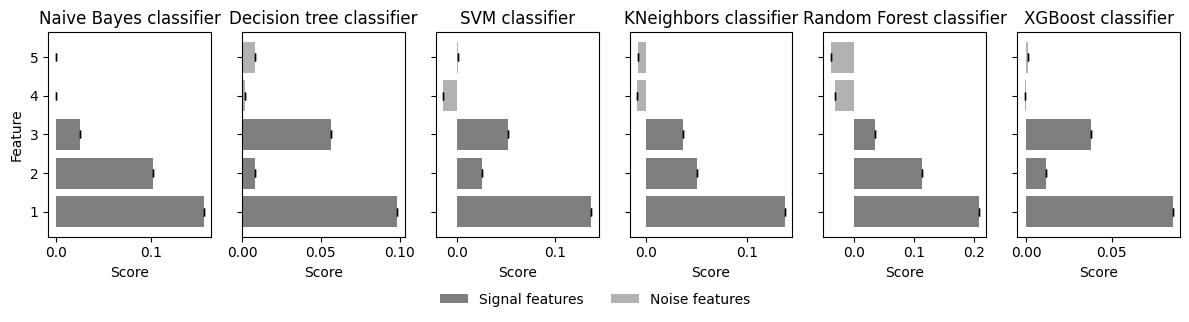

In [46]:
fig, ax = plt.subplots(1, 6, figsize=(12, 3), sharey=True)

metrics = [
    (g_NB[:, reorder], "Naive Bayes classifier"),
    (g_DT[:, reorder], "Decision tree classifier"),
    (g_SVC[:, reorder], "SVM classifier"),
    (g_KN[:, reorder], "KNeighbors classifier"),
    (g_RF[:, reorder], "Random Forest classifier"),
    (g_xg[:, reorder], "XGBoost classifier"),
]
y = np.arange(X.shape[1])

colors = ["tab:gray"] * X.shape[1]
alphas = np.array([1.0, 1.0, 1.0, 0.6, 0.6])


for a, (g, title) in zip(ax, metrics):
    mean = np.nanmean(g, axis=0)
    se = np.nanstd(g, axis=0, ddof=1) #  / np.sqrt(np.sum(~np.isnan(g), axis=0))

    bars = a.barh(y, mean, xerr=se, capsize=3, color=colors)

    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)

    a.set_title(title)
    a.set_xlabel("Score")
    a.set_yticks(y)
    a.set_yticklabels(np.arange(1, X.shape[1] + 1))
    a.invert_yaxis()

ax[0].set_ylabel("Feature")

legend_handles = [
    Patch(facecolor="tab:gray", alpha=1.0, label="Signal features"),
    Patch(facecolor="tab:gray", alpha=0.6, label="Noise features"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.08),
    frameon=False,
)

plt.tight_layout()
# fig.savefig("../figures/comparison_20runs_toyexample.png", bbox_inches="tight")
plt.show()

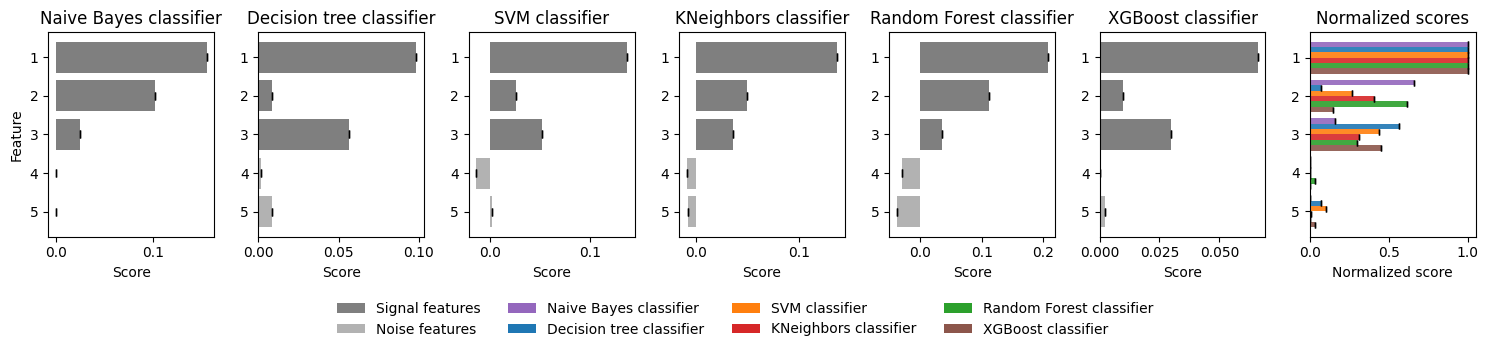

In [ ]:
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 7, figsize=(15, 3), sharey=False)

method_colors = {
    "Decision tree classifier": "tab:blue",
    "SVM classifier": "tab:orange",
    "Random Forest classifier": "tab:green",
    "KNeighbors classifier": "tab:red",
    "Naive Bayes classifier": "tab:purple",
    "XGBoost classifier": "tab:brown"
}

y = np.arange(X.shape[1])

feature_colors = ["tab:gray"] * X.shape[1]
feature_alphas = np.array([1.0, 1.0, 1.0, 0.6, 0.6])

# ---- first five panels: raw scores ----
for a, (g, title) in zip(ax[:-1], metrics):
    mean = np.nanmean(g, axis=0)
    se = np.nanstd(g, axis=0, ddof=1)

    bars = a.barh(
        y,
        mean,
        xerr=se,
        capsize=3,
        color=feature_colors,
    )

    for bar, alpha in zip(bars, feature_alphas):
        bar.set_alpha(alpha)

    a.set_title(title)
    a.set_xlabel("Score")
    a.set_yticks(y)
    a.set_yticklabels(np.arange(1, X.shape[1] + 1))
    a.invert_yaxis()

ax[0].set_ylabel("Feature")

# ---- sixth panel: normalized scores by method ----
norm_means = []
norm_ses = []
method_names = []

for g, title in metrics:
    # normalize each run across features, then average across runs
    g_norm = np.apply_along_axis(normalize, 1, g)

    norm_means.append(np.nanmean(g_norm, axis=0))
    norm_ses.append(np.nanstd(g_norm, axis=0, ddof=1))
    method_names.append(title)

norm_means = np.asarray(norm_means)  # shape: (n_methods, n_features)
norm_ses = np.asarray(norm_ses)

# Put all methods side-by-side for each feature
width = 0.14
offsets = (np.arange(len(metrics)) - (len(metrics) - 1) / 2) * width

for method_idx, title in enumerate(method_names):
    ax[-1].barh(
        y + offsets[method_idx],
        norm_means[method_idx],
        xerr=norm_ses[method_idx],
        height=width,
        capsize=2,
        color=method_colors[title],
        alpha=0.9,
        label=title,
    )

ax[-1].set_title("Normalized scores")
ax[-1].set_xlabel("Normalized score")
ax[-1].set_yticks(y)
ax[-1].set_yticklabels(np.arange(1, X.shape[1] + 1))
ax[-1].invert_yaxis()

# ---- legends ----
feature_legend_handles = [
    Patch(facecolor="tab:gray", alpha=1.0, label="Signal features"),
    Patch(facecolor="tab:gray", alpha=0.6, label="Noise features"),
]

method_legend_handles = [
    Patch(facecolor=method_colors[name], label=name)
    for name in method_names
]

fig.legend(
    handles=feature_legend_handles + method_legend_handles,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.18),
    frameon=False,
)

plt.tight_layout()
# fig.savefig("../figures/comparison_20runs_toyexample.png", bbox_inches="tight")
plt.show()